In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("NYPD.csv")

In [12]:
df.isna().sum()
df.dropna(inplace=True)

In [15]:
df["LOCATION_DESC"].dtype

dtype('O')

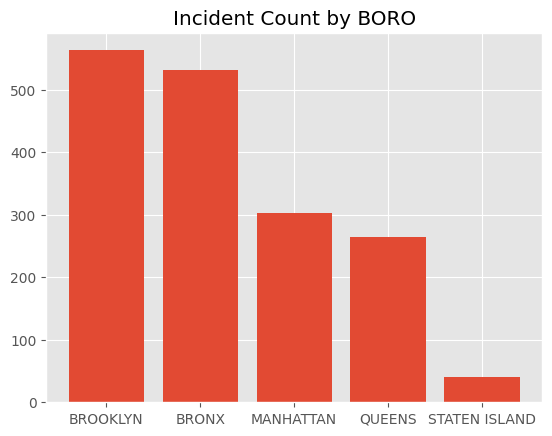

In [18]:
boros = df.value_counts("BORO")
plt.style.use('ggplot')
plt.bar(boros.index,boros.values)
plt.title("Incident Count by BORO");

In [26]:
inc = df.groupby(["STATISTICAL_MURDER_FLAG", 'BORO'])['INCIDENT_KEY'].count()

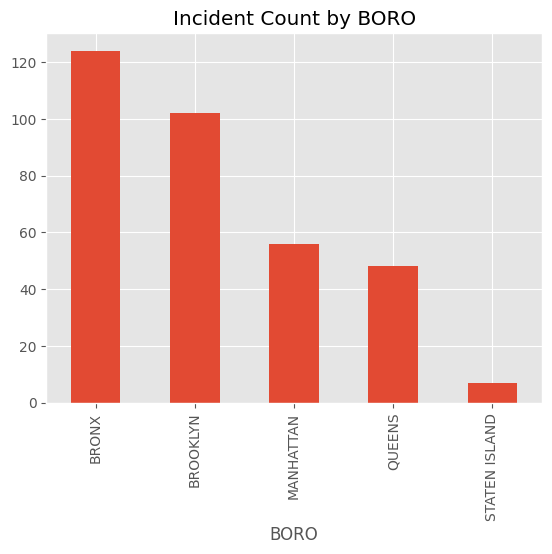

In [34]:
inc.loc["Y"].plot(kind="bar")
plt.style.use('ggplot')
plt.title("Incident Count by BORO");

Text(0.5, 1.0, 'New York City')

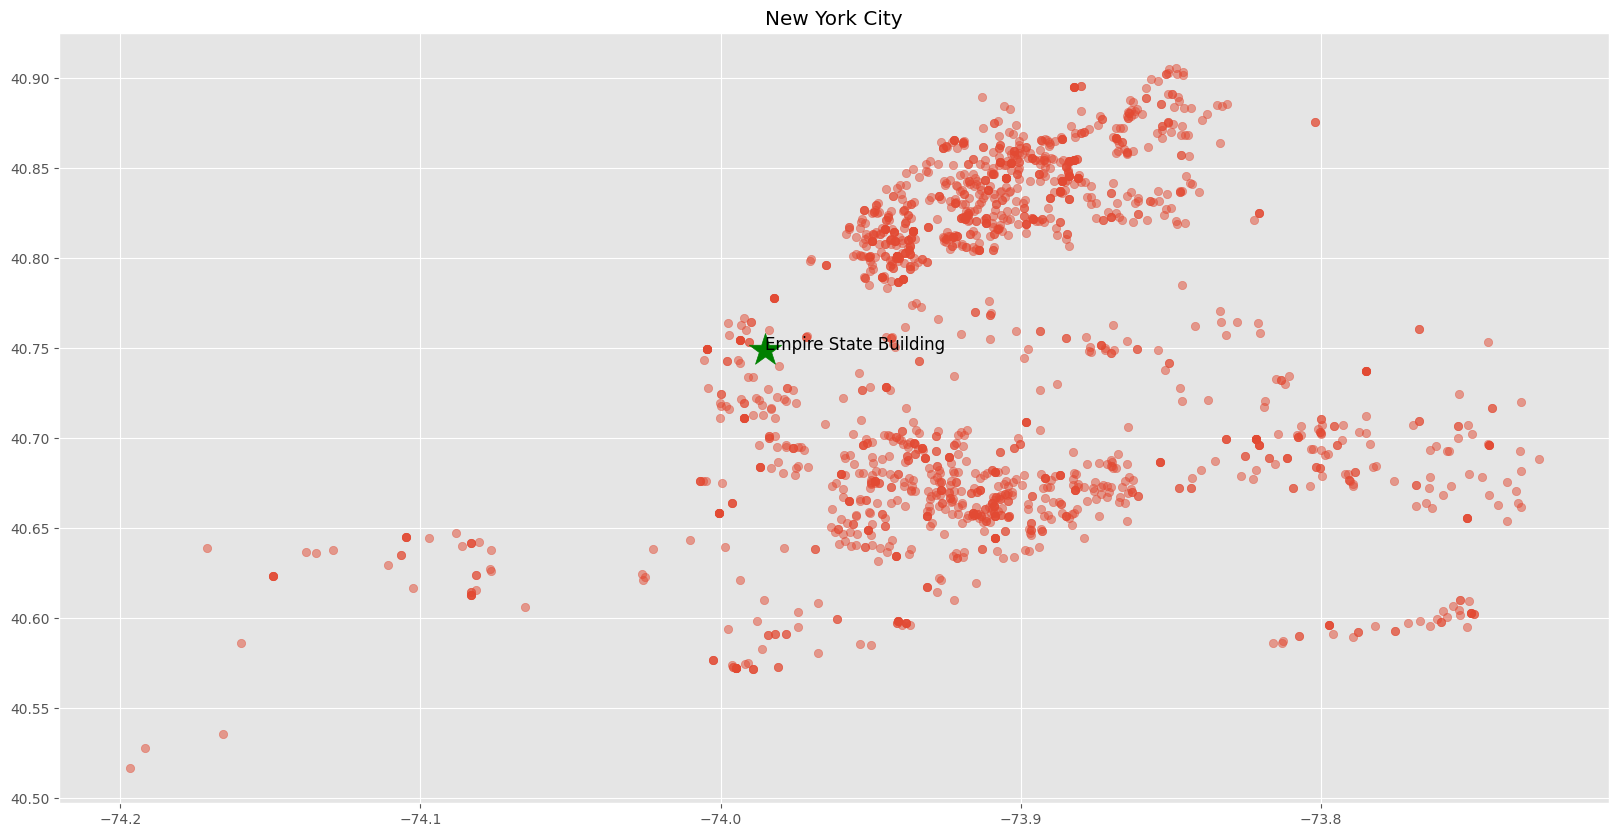

In [58]:
plt.figure(figsize=(20,10))
plt.scatter(df['Longitude'],df['Latitude'], alpha=0.5)
plt.scatter(-73.9854,40.7488, c="green",s=600, marker="*")
plt.annotate("Empire State Building", (-73.9854,40.7488),fontsize=12)
plt.title("New York City")

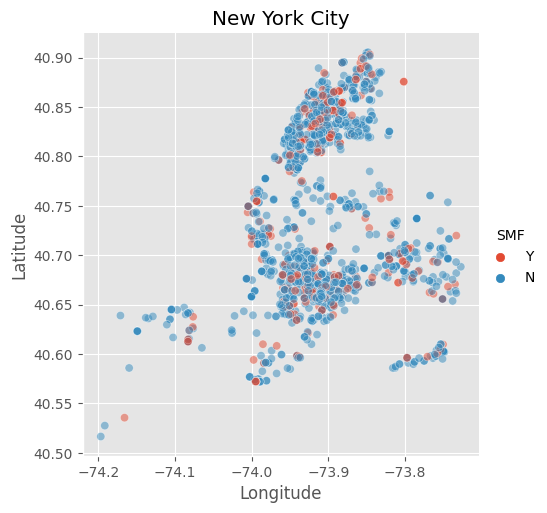

In [66]:
df.rename(columns={"STATISTICAL_MURDER_FLAG":"SMF"}, inplace=True)
sns.relplot(x="Longitude", y="Latitude", 
            hue='SMF', 
            alpha=.5, data=df)
plt.title("New York City");

In [70]:
# df['OCCUR_TIME'].str.split(":", expand=True)

In [71]:
df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'])

/var/folders/h9/dpt3wtdd7ln_h9qq7dgqw_v80000gn/T/ipykernel_90141/3820038883.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'])


In [73]:
df["Hour"] = df["OCCUR_TIME"].dt.hour

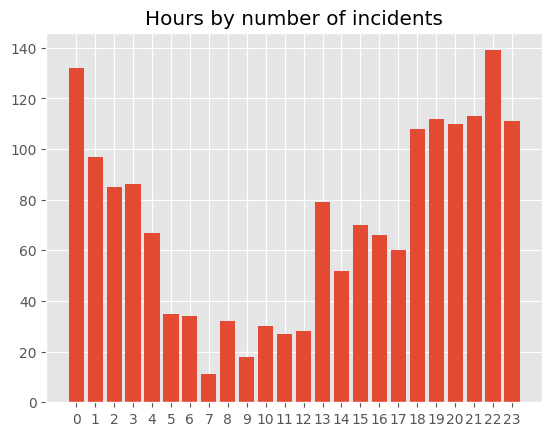

In [79]:
# Plot as bar hours by number of incidents
hours = df["Hour"].value_counts()
plt.bar(hours.index,hours )
plt.xticks(range(24))
plt.title("Hours by number of incidents");
# use apply and lambda and replace Y with 1 and N with 0 
# in SMF column

In [80]:
df["SMF"] = df["SMF"].apply(lambda x: 1 if x == "Y" else 0)

In [84]:
df["N"] = ""

In [87]:
# help(pd.DataFrame)

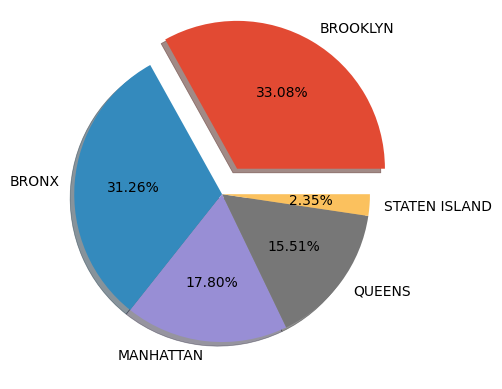

In [95]:
boros = df.value_counts("BORO")
plt.pie(boros, labels=boros.index, 
        shadow=True, 
        explode=[0.2,0,0,0,0],
        autopct="%.2f%%");